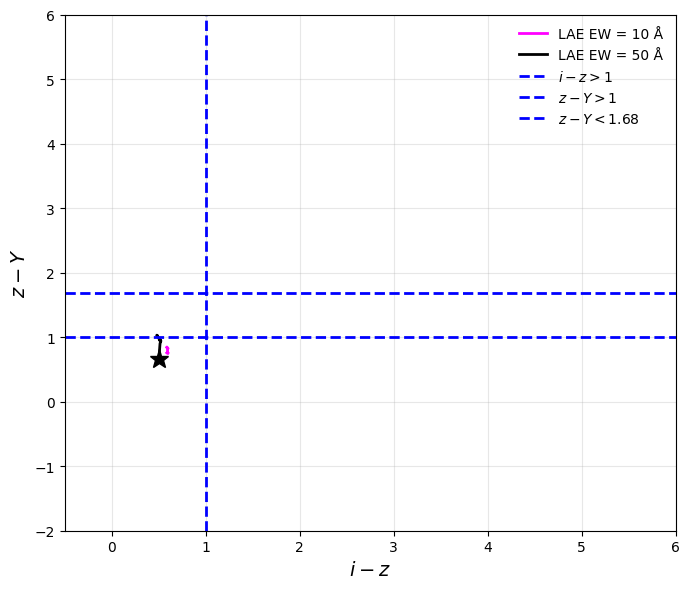

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from synphot import SourceSpectrum, SpectralElement, Observation
from synphot.models import PowerLawFlux1D, GaussianFlux1D, Empirical1D

# ============================================================
# 1. LOAD DECam FILTERS
# ============================================================

f_i = SpectralElement.from_file("/Users/aishwarya/Downloads/CTIO_DECam.i.dat")
f_z = SpectralElement.from_file("/Users/aishwarya/Downloads/CTIO_DECam.z.dat")
f_y = SpectralElement.from_file("/Users/aishwarya/Downloads/CTIO_DECam.Y.dat")

# ============================================================
# 2. CONTINUUM (PHOTLAM)
# ============================================================

beta = -2.0

continuum = SourceSpectrum(
    PowerLawFlux1D,
    amplitude=1.0 * u.photon / u.s / u.cm**2 / u.AA,
    x_0=1216.0 * u.AA,
    alpha=beta
)

# ============================================================
# 3. LAE SPECTRUM WITH EW
# ============================================================

def make_lae_spectrum(EW_rest):
    """
    Synthetic LAE spectrum with rest-frame EW (Å)
    """

    f_cont = continuum(1216.0 * u.AA).value  # PHOTLAM

    fwhm = 2.0  # Å
    sigma = fwhm / 2.355

    amp = (EW_rest * f_cont) / (np.sqrt(2 * np.pi) * sigma)

    lya_line = SourceSpectrum(
        GaussianFlux1D,
        mean=1215.67 * u.AA,
        amplitude=amp * u.photon / u.s / u.cm**2 / u.AA,
        stddev=sigma * u.AA
    )

    return continuum + lya_line

# ============================================================
# 4. EXPLICIT REDSHIFTING FUNCTION (SAFE METHOD)
# ============================================================

def redshift_spectrum(spec, z, wave):
    """
    Redshift a SourceSpectrum explicitly using Empirical1D
    """

    flux = spec(wave)
    wave_z = wave * (1.0 + z)

    return SourceSpectrum(
        Empirical1D,
        points=wave_z,
        lookup_table=flux
    )

# ============================================================
# 5. REDSHIFT GRID
# ============================================================

z_grid = np.linspace(6.5, 7.2, 40)

# Wavelength grid (must cover i,z,Y at z~7)
wave = np.linspace(800, 13000, 20000) * u.AA

# ============================================================
# 6. COLOR TRACKS
# ============================================================

def compute_color_track(EW):
    iz, zy = [], []

    base_spec = make_lae_spectrum(EW)

    for z in z_grid:
        spec_z = redshift_spectrum(base_spec, z, wave)

        obs_i = Observation(spec_z, f_i)
        obs_z = Observation(spec_z, f_z)
        obs_y = Observation(spec_z, f_y)

        mi = obs_i.effstim("abmag")
        mz = obs_z.effstim("abmag")
        my = obs_y.effstim("abmag")

        iz.append(mi - mz)
        zy.append(mz - my)

    return np.array(iz), np.array(zy)

# ============================================================
# 7. COMPUTE TRACKS
# ============================================================

iz_10, zy_10 = compute_color_track(10)
iz_50, zy_50 = compute_color_track(50)

z_idx = np.argmin(np.abs(z_grid - 6.9))

# ============================================================
# 8. PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(iz_10, zy_10, color="magenta", lw=2, label="LAE EW = 10 Å")
ax.plot(iz_50, zy_50, color="black", lw=2, label="LAE EW = 50 Å")

ax.plot(
    iz_50[z_idx], zy_50[z_idx],
    marker="*", color="black", ms=14
)

# Selection cuts
ax.axvline(1.0, color="blue", lw=2, ls="--", label=r"$i-z>1$")
ax.axhline(1.0, color="blue", lw=2, ls="--", label=r"$z-Y>1$")
ax.axhline(1.68, color="blue", lw=2, ls="--", label=r"$z-Y<1.68$")

ax.set_xlabel(r"$i-z$", fontsize=14)
ax.set_ylabel(r"$z-Y$", fontsize=14)
ax.set_xlim(-0.5, 6)
ax.set_ylim(-2, 6)

ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


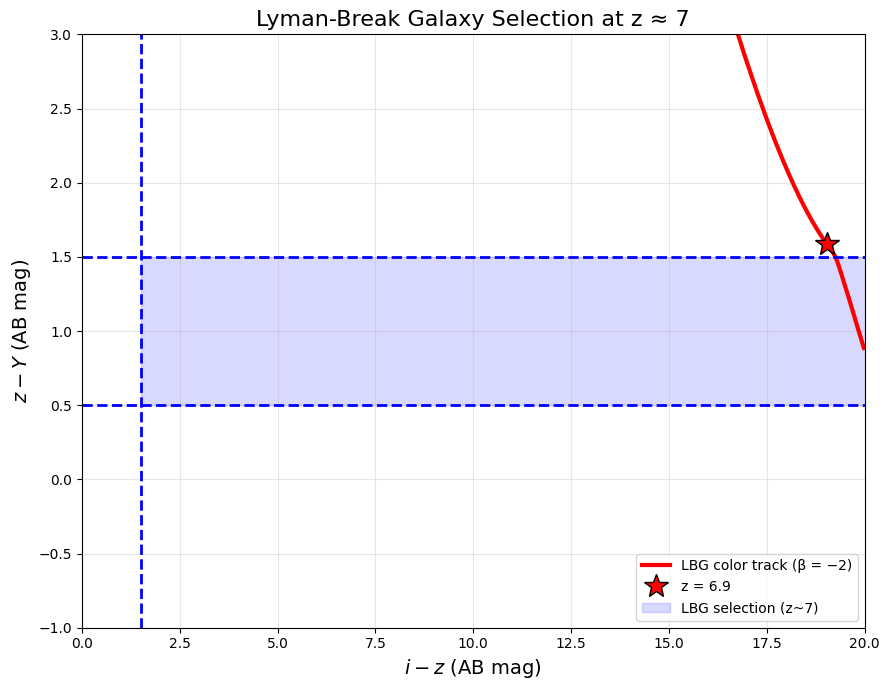

LBG SELECTION SUMMARY
Redshift grid: 6.50 – 7.20
Selected redshift range: 6.50 – 6.81
Number of selected points: 18
Selection:
  i − z > 1.5
  0.5 < z − Y < 1.5


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from synphot import SourceSpectrum, SpectralElement, Observation
from synphot.models import PowerLawFlux1D, Empirical1D
from synphot.exceptions import SynphotError

# ============================================================
# 1. LOAD DECam FILTERS
# ============================================================

f_i = SpectralElement.from_file("/Users/aishwarya/Downloads/CTIO_DECam.i.dat")
f_z = SpectralElement.from_file("/Users/aishwarya/Downloads/CTIO_DECam.z.dat")
f_y = SpectralElement.from_file("/Users/aishwarya/Downloads/CTIO_DECam.Y.dat")

# ============================================================
# 2. LBG CONTINUUM (PHOTLAM)
# ============================================================

beta = -2.0

continuum = SourceSpectrum(
    PowerLawFlux1D,
    amplitude=1.0 * u.photon / u.s / u.cm**2 / u.AA,
    x_0=1500.0 * u.AA,
    alpha=beta
)

# ============================================================
# 3. IGM ABSORPTION (COMPLETE CUTOFF)
# ============================================================

def apply_igm_absorption(wave_rest, flux_rest):
    flux = flux_rest.copy()
    flux[wave_rest < 1216 * u.AA] = 0.0 * flux.unit
    return flux

# ============================================================
# 4. REDSHIFT SPECTRUM
# ============================================================

def redshift_lbg_spectrum(spec, z, wave_rest):
    flux_rest = spec(wave_rest)
    flux_rest = apply_igm_absorption(wave_rest, flux_rest)

    wave_obs = wave_rest * (1.0 + z)

    return SourceSpectrum(
        Empirical1D,
        points=wave_obs,
        lookup_table=flux_rest
    )

# ============================================================
# 5. SAFE AB MAGNITUDE (SURVEY DEPTH LIMITED)
# ============================================================

def safe_abmag(obs, faint_mag=28.0):
    try:
        return obs.effstim("abmag").value
    except SynphotError:
        return faint_mag

# ============================================================
# 6. GRIDS
# ============================================================

z_grid = np.linspace(6.5, 7.2, 40)
wave = np.linspace(800, 13000, 20000) * u.AA

# ============================================================
# 7. LBG COLOR TRACK
# ============================================================

def compute_lbg_color_track():
    iz, zy = [], []

    for z in z_grid:
        spec_z = redshift_lbg_spectrum(continuum, z, wave)

        obs_i = Observation(spec_z, f_i)
        obs_z = Observation(spec_z, f_z)
        obs_y = Observation(spec_z, f_y)

        mi = safe_abmag(obs_i)
        mz = safe_abmag(obs_z)
        my = safe_abmag(obs_y)

        iz.append(mi - mz)
        zy.append(mz - my)

    return np.array(iz), np.array(zy)

# ============================================================
# 8. COMPUTE
# ============================================================

iz_lbg, zy_lbg = compute_lbg_color_track()
z_idx = np.argmin(np.abs(z_grid - 6.9))

# ============================================================
# 9. PLOT (LBG SELECTION)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

# LBG color track
ax.plot(
    iz_lbg, zy_lbg,
    color="red", lw=3, label="LBG color track (β = −2)"
)

ax.plot(
    iz_lbg[z_idx], zy_lbg[z_idx],
    "*", ms=18, color="red",
    markeredgecolor="black",
    label="z = 6.9"
)

# Selection box: i-z > 1.5 and 0.5 < z-Y < 1.5
selection_box = plt.Rectangle(
    (1.5, 0.5), 20, 1.0,
    color="blue", alpha=0.15,
    label="LBG selection (z~7)"
)
ax.add_patch(selection_box)

# Selection lines
ax.axvline(1.5, color="blue", ls="--", lw=2)
ax.axhline(0.5, color="blue", ls="--", lw=2)
ax.axhline(1.5, color="blue", ls="--", lw=2)

ax.set_xlabel(r"$i-z$ (AB mag)", fontsize=14)
ax.set_ylabel(r"$z-Y$ (AB mag)", fontsize=14)

# IMPORTANT: expanded x-axis for LBGs
ax.set_xlim(0, 20)
ax.set_ylim(-1, 3)

ax.set_title("Lyman-Break Galaxy Selection at z ≈ 7", fontsize=16)
ax.legend(frameon=True)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 10. SELECTION DIAGNOSTICS
# ============================================================

selected = (iz_lbg > 1.5) & (zy_lbg > 0.5) & (zy_lbg < 1.5)
selected_z = z_grid[selected]

print("=" * 60)
print("LBG SELECTION SUMMARY")
print("=" * 60)
print(f"Redshift grid: {z_grid[0]:.2f} – {z_grid[-1]:.2f}")
print(f"Selected redshift range: {selected_z[0]:.2f} – {selected_z[-1]:.2f}")
print(f"Number of selected points: {len(selected_z)}")
print("Selection:")
print("  i − z > 1.5")
print("  0.5 < z − Y < 1.5")
print("=" * 60)
